# Homework 3: CNN

Download/Load MNIST dataset

In [1]:
TrainingFolder = './Training'
TestingFolder = './Testing'

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train = ImageDataGenerator(shear_range = 0.1, zoom_range = 0.1, horizontal_flip = True)
test = ImageDataGenerator()

In [4]:
trainSet = train.flow_from_directory(TrainingFolder, target_size = (64, 64), batch_size = 32, class_mode = 'categorical')
testSet = test.flow_from_directory(TestingFolder, target_size = (64, 64), batch_size = 32, class_mode = 'categorical')

Found 244 images belonging to 16 classes.


Found 64 images belonging to 16 classes.


Creating Mapping

In [5]:
classes = trainSet.class_indices
mapping = {}

for value, name in zip(classes.values(), classes.keys()):
    mapping[value] = name

In [6]:
import pickle

In [ ]:
with  open('Mapping.pkl', 'wb') as f:
    pickle.dump(mapping, f)

neurons = len(mapping)

print(f"Mapped Faces and ID's: {mapping}")
print(f'\nOutput Neurons: {neurons}')

Mapped Faces and ID's: {0: 'face1', 1: 'face10', 2: 'face11', 3: 'face12', 4: 'face13', 5: 'face14', 6: 'face15', 7: 'face16', 8: 'face2', 9: 'face3', 10: 'face4', 11: 'face5', 12: 'face6', 13: 'face7', 14: 'face8', 15: 'face9'}

Output Neurons: 16


Creating CNN

In [8]:
from keras.models import Sequential
from keras.layers import Convolution2D, AveragePooling2D, Flatten, Dense

In [9]:
''' ____ Model 1 ____ '''
model_1 = Sequential()

''' Layers '''
# Layer 1
model_1.add(Convolution2D(16, kernel_size = (4, 4), strides = (1, 1), input_shape=(64, 64, 3), activation = 'tanh'))
model_1.add(AveragePooling2D(pool_size = (2, 2)))

# Layer 2
model_1.add(Convolution2D(32, kernel_size = (4, 4), strides = (1, 1), activation = 'tanh'))
model_1.add(AveragePooling2D(pool_size = (2, 2)))

# Layer 3
model_1.add(Convolution2D(64, kernel_size = (4, 4), strides = (1, 1), activation = 'tanh'))
model_1.add(AveragePooling2D(pool_size = (2, 2)))

# Flattening
model_1.add(Flatten())

# Dense
model_1.add(Dense(32, activation = 'tanh'))
model_1.add(Dense(neurons, activation = 'sigmoid'))

''' ____ Model 2 ____ (Reducing just Pooling size) '''
model_2 = Sequential()

''' Layers '''
# Layer 1
model_2.add(Convolution2D(16, kernel_size = (4, 4), strides = (1, 1), input_shape=(64, 64, 3), activation = 'tanh'))
model_2.add(AveragePooling2D(pool_size = (1, 1)))

# Layer 2
model_2.add(Convolution2D(32, kernel_size = (4, 4), strides = (1, 1), activation = 'tanh'))
model_2.add(AveragePooling2D(pool_size = (1, 1)))

# Layer 3
model_2.add(Convolution2D(64, kernel_size = (4, 4), strides = (1, 1), activation = 'tanh'))
model_2.add(AveragePooling2D(pool_size = (1, 1)))

# Flattening
model_2.add(Flatten())

# Dense
model_2.add(Dense(32, activation = 'tanh'))
model_2.add(Dense(neurons, activation = 'sigmoid'))

c:\Users\luisp\anaconda3\envs\machine\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile CNN

In [10]:
model_1.compile(loss = 'categorical_crossentropy', optimizer = 'adamW', metrics = ['accuracy'])
model_2.compile(loss = 'categorical_crossentropy', optimizer = 'adamW', metrics = ['accuracy'])

Training

In [11]:
import time

In [12]:
histories = []
models = [model_1, model_2]

for idx, mdl in enumerate(models, start = 1):
    start = time.time()

    history = mdl.fit(
        trainSet,
        steps_per_epoch = len(trainSet),
        epochs = 24,
        validation_data = testSet,
        validation_steps = 20,
        verbose = 0)
    histories.append(history)

    end = time.time()

    print(f'Total Time: (model {idx}) {round(end-start)}s')

model_1, model_2 = models

c:\Users\luisp\anaconda3\envs\machine\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\luisp\anaconda3\envs\machine\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Total Time: (model 1) 20s
Total Time: (model 2) 34s


Predict

In [13]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

models = [model_1, model_2]

for face in range(16):
    print(f'Face: {face + 1}')
    path = f'./Testing/face{face + 1}/2face{face + 1}.jpg'

    testImage = load_img(path, target_size=(64, 64))
    testImage = img_to_array(testImage)

    testImage = np.expand_dims(testImage, axis=0)

    for idx, mod in enumerate(models, start=1):
        prediction = mod.predict(testImage, verbose=0)
        pred_class = mapping[np.argmax(prediction)]

        print(f'Model {idx} prediction: {pred_class}')

    print()

Face: 1
Model 1 prediction: face1
Model 2 prediction: face10

Face: 2
Model 1 prediction: face2
Model 2 prediction: face10

Face: 3
Model 1 prediction: face3
Model 2 prediction: face10

Face: 4
Model 1 prediction: face4
Model 2 prediction: face10

Face: 5
Model 1 prediction: face5
Model 2 prediction: face10

Face: 6
Model 1 prediction: face6
Model 2 prediction: face10

Face: 7
Model 1 prediction: face7
Model 2 prediction: face10

Face: 8
Model 1 prediction: face8
Model 2 prediction: face10

Face: 9
Model 1 prediction: face9
Model 2 prediction: face10

Face: 10
Model 1 prediction: face10
Model 2 prediction: face10

Face: 11
Model 1 prediction: face11
Model 2 prediction: face10

Face: 12
Model 1 prediction: face12
Model 2 prediction: face10

Face: 13
Model 1 prediction: face13
Model 2 prediction: face10

Face: 14
Model 1 prediction: face14
Model 2 prediction: face10

Face: 15
Model 1 prediction: face15
Model 2 prediction: face10

Face: 16
Model 1 prediction: face16
Model 2 prediction: fa

Plots

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

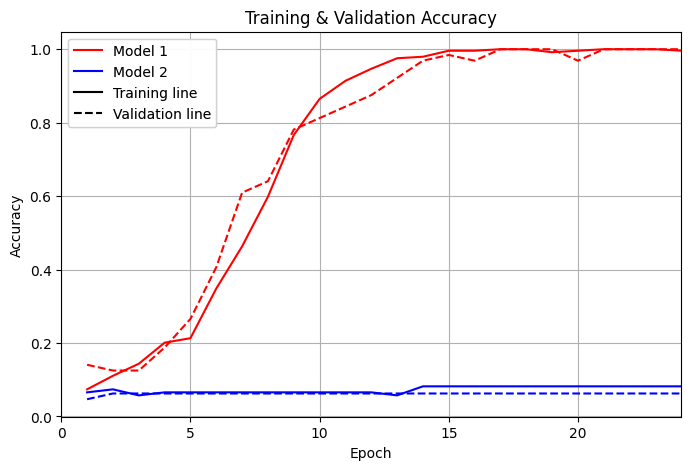

In [15]:
acc_key = 'accuracy' if 'accuracy' in histories[0].history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in histories[0].history else 'val_acc'

epochs = range(1, len(histories[0].history['loss']) + 1)

colors = ['r', 'b']

plt.figure(figsize=(8,5))

for idx, history in enumerate(histories[:2], start=1):
    acc = history.history[acc_key]
    val_acc = history.history[val_acc_key]
    color = colors[idx-1]

    plt.plot(epochs, acc, linestyle='-', color=color)
    plt.plot(epochs, val_acc, linestyle='--', color=color)

plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xlim([0, 24])
plt.grid(True)

model_lines = [
    Line2D([0], [0], color='r', linestyle='-'),
    Line2D([0], [0], color='b', linestyle='-'),
    Line2D([0], [0], color='k', linestyle='-'),
    Line2D([0], [0], color='k', linestyle='--')
]
legend1 = plt.legend(model_lines, ['Model 1', 'Model 2', 'Training line', 'Validation line'], loc='upper left')
plt.gca().add_artist(legend1)
plt.show()

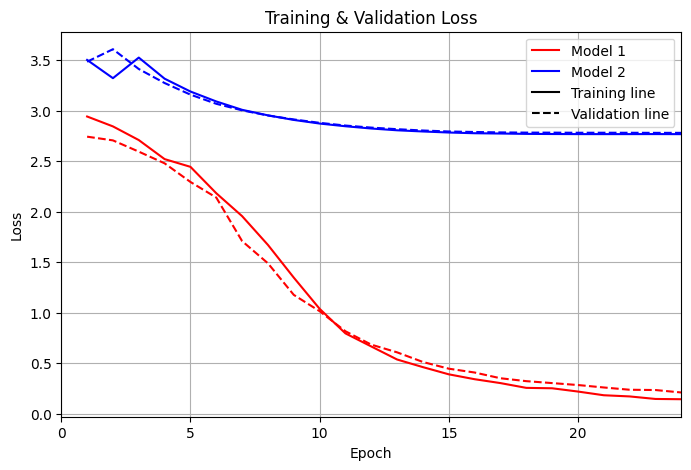

In [16]:
loss_epochs = range(1, len(histories[0].history['loss']) + 1)

colors = ['r', 'b']

plt.figure(figsize=(8,5))

for idx, history in enumerate(histories[:2], start=1):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    color = colors[idx-1]

    plt.plot(loss_epochs, loss, linestyle='-', color=color)
    plt.plot(loss_epochs, val_loss, linestyle='--', color=color)

plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xlim([0, 24])
plt.grid(True)

from matplotlib.lines import Line2D
model_lines = [
    Line2D([0], [0], color='r', linestyle='-'),
    Line2D([0], [0], color='b', linestyle='-'),
    Line2D([0], [0], color='k', linestyle='-'),
    Line2D([0], [0], color='k', linestyle='--')
]
plt.legend(model_lines, ['Model 1', 'Model 2', 'Training line', 'Validation line'],
           loc='upper right')

plt.show()

In [20]:
import itertools

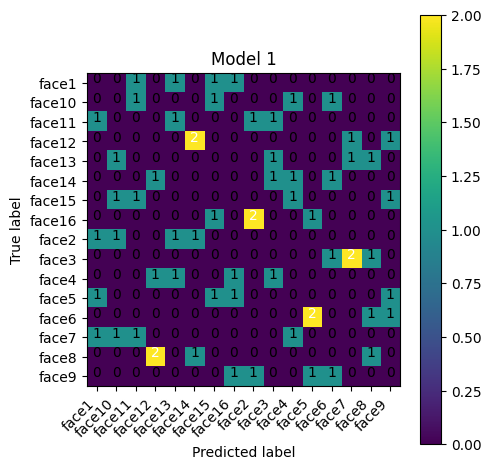

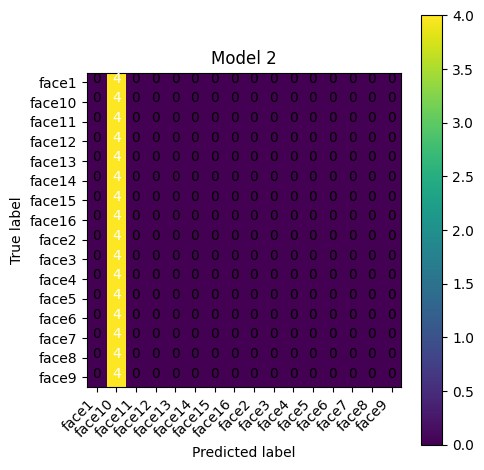

In [21]:
y_true = testSet.classes

class_indices = trainSet.class_indices  # {'clase': idx}
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

def plot_confusion_matrix(cm, classes, title='Confusion matrix'):
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 45, ha='right')
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment = 'center',
                 color = 'white' if cm[i, j] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

for i, model in enumerate(models, start = 1):
    testSet.reset()
    y_prob = model.predict(testSet, verbose = 0)
    y_pred = np.argmax(y_prob, axis = 1)

    n_classes = len(class_names)
    cm = np.zeros((n_classes, n_classes), dtype = int)

    np.add.at(cm, (y_true, y_pred), 1)

    plt.figure(figsize=(5,5))
    plot_confusion_matrix(cm, classes = class_names, title=f'Model {i}')
    plt.show()
